In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.read_csv("/content/drive/MyDrive/heart_attack_risk_dataset.csv")

In [4]:
data.head(10)

,Age,Gender,Smoking,Alcohol_Consumption,Physical_Activity_Level,BMI,Diabetes,Hypertension,Cholesterol_Level,Resting_BP,Heart_Rate,Family_History,Stress_Level,Chest_Pain_Type,Thalassemia,Fasting_Blood_Sugar,ECG_Results,Exercise_Induced_Angina,Max_Heart_Rate_Achieved,Heart_Attack_Risk
0,69,Female,1,0,Moderate,34.61,1,0,152.1,171,85,0,Moderate,Non-anginal,Reversible defect,0,Normal,0,114,Low
1,32,Male,0,0,Moderate,22.75,0,0,166.8,126,103,0,Low,Asymptomatic,Normal,0,ST-T abnormality,0,173,Moderate
2,89,Male,0,1,Moderate,35.32,0,0,272.3,123,127,0,Low,Typical,Reversible defect,0,ST-T abnormality,0,109,Low
3,78,Male,0,1,Moderate,18.23,1,0,237.7,144,125,0,Low,Typical,Fixed defect,1,Left Ventricular Hypertrophy,0,129,Low
4,38,Female,1,0,Moderate,19.82,0,0,207.7,123,107,0,High,Asymptomatic,Reversible defect,0,ST-T abnormality,0,124,Moderate
5,41,Male,0,1,Moderate,36.11,0,0,271.2,141,119,0,Low,Atypical,Fixed defect,0,Normal,0,101,High
6,20,Male,1,0,Low,15.12,0,0,164.8,154,67,0,Low,Non-anginal,Normal,0,Normal,0,176,Low
7,39,Female,0,0,Moderate,20.78,0,0,297.0,91,112,0,Low,Atypical,Normal,0,ST-T abnormality,1,134,Moderate
8,70,Male,0,1,High,29.20,0,0,280.7,121,71,0,Moderate,Non-anginal,Fixed defect,0,ST-T abnormality,0,168,Moderate
9,19,Female,0,0,High,35.54,0,1,275.0,167,76,0,Low,Typical,Reversible defect,1,Left Ventricular Hypertrophy,0,102,Moderate


In [5]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      50000 non-null  int64  
 1   Gender                   50000 non-null  object 
 2   Smoking                  50000 non-null  int64  
 3   Alcohol_Consumption      50000 non-null  int64  
 4   Physical_Activity_Level  50000 non-null  object 
 5   BMI                      50000 non-null  float64
 6   Diabetes                 50000 non-null  int64  
 7   Hypertension             50000 non-null  int64  
 8   Cholesterol_Level        50000 non-null  float64
 9   Resting_BP               50000 non-null  int64  
 10  Heart_Rate               50000 non-null  int64  
 11  Family_History           50000 non-null  int64  
 12  Stress_Level             50000 non-null  object 
 13  Chest_Pain_Type          50000 non-null  object 
 14  Thalassemia           

In [10]:
categorical_columns = [
    'Gender', 'Smoking', 'Alcohol_Consumption', 'Physical_Activity_Level',
    'Diabetes', 'Hypertension', 'Cholesterol_Level', 'Family_History',
    'Stress_Level', 'Chest_Pain_Type', 'Thalassemia', 'Fasting_Blood_Sugar',
    'ECG_Results', 'Exercise_Induced_Angina', 'Heart_Attack_Risk'
]

In [13]:
label_encoder = LabelEncoder()

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [14]:
# Split the data into training and testing sets (80% training, 20% testing)
X = data.drop(columns=['Heart_Attack_Risk'])
y = data['Heart_Attack_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)


In [15]:
model = DecisionTreeClassifier(random_state=123)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=123)

In [21]:
class_names = [str(cls) for cls in model.classes_]

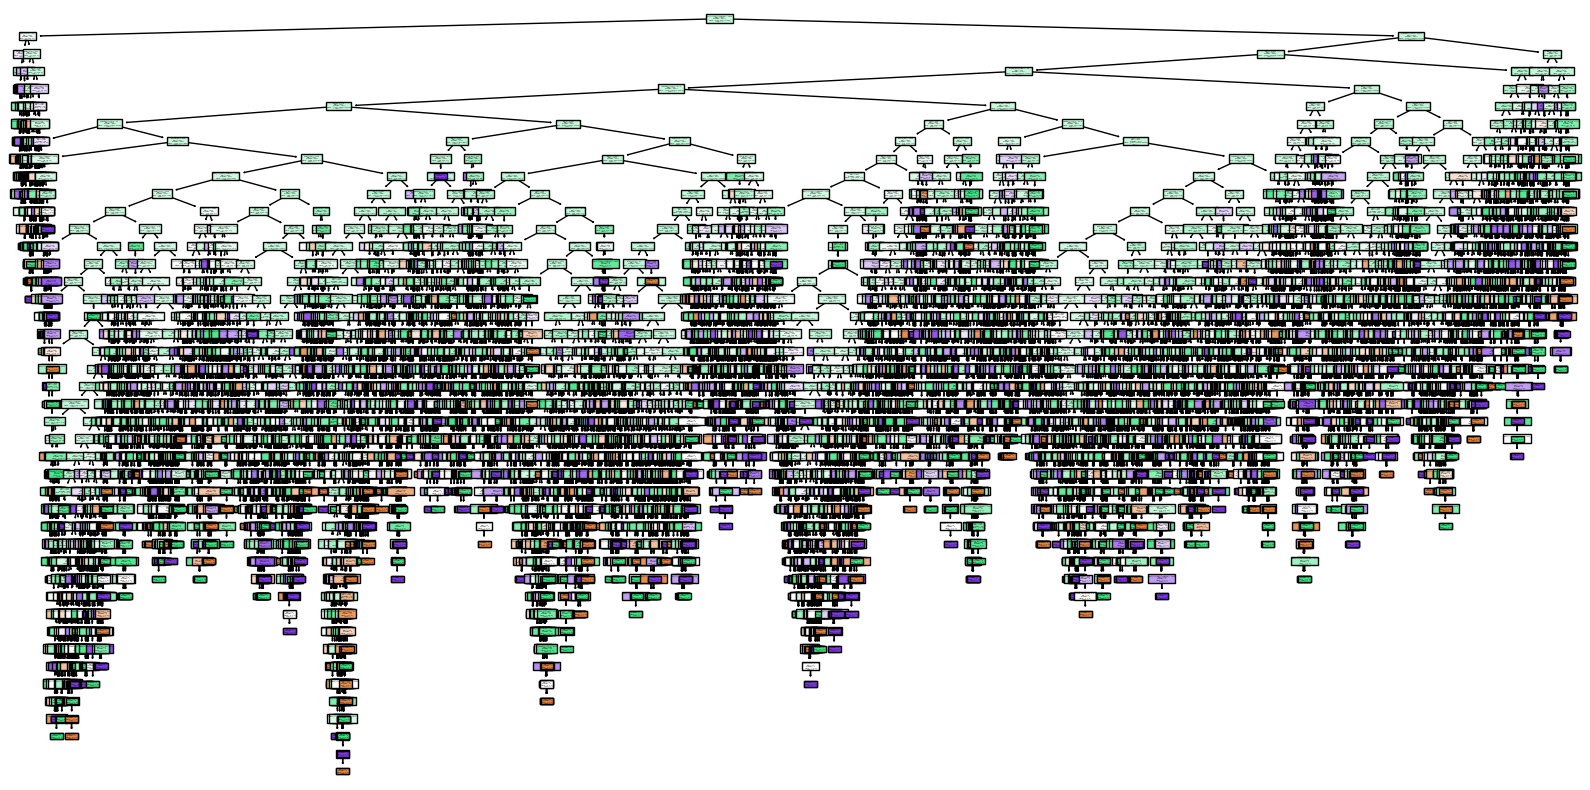

In [23]:
plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=X.columns, class_names=class_names, filled=True)
plt.show()

In [24]:
# Make predictions on the test set
predictions = model.predict(X_test)

In [25]:
cm = confusion_matrix(y_test, predictions)

In [26]:
cm

array([[ 426,  995,  619],
       [1080, 2343, 1533],
       [ 640, 1479,  885]])

In [27]:
accuracy = accuracy_score(y_test, predictions)

In [28]:
accuracy

0.3654

In [30]:
from sklearn.metrics import classification_report

report = classification_report(y_test, predictions)

In [31]:
report

'              precision    recall  f1-score   support\n\n           0       0.20      0.21      0.20      2040\n           1       0.49      0.47      0.48      4956\n           2       0.29      0.29      0.29      3004\n\n    accuracy                           0.37     10000\n   macro avg       0.33      0.33      0.33     10000\nweighted avg       0.37      0.37      0.37     10000\n'